# MVTec AD Dataset Exploration

This notebook explores the structure and contents of the MVTec AD industrial anomaly detection dataset.

Initial objectives:

- verify the dataset path,
- inspect available object categories,
- examine the `bottle` category,
- count normal and defective images,
- inspect available ground-truth masks.

In [2]:
from pathlib import Path

PROJECT_ROOT = Path(r"D:\PROJECTS\ANOMALY DETECTION")
DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "mvtec_ad"

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATASET_ROOT)
print("Dataset exists:", DATASET_ROOT.exists())

Project root: D:\PROJECTS\ANOMALY DETECTION
Dataset root: D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_ad
Dataset exists: True


In [3]:
categories = sorted(
    folder.name
    for folder in DATASET_ROOT.iterdir()
    if folder.is_dir()
)

print(f"Number of categories: {len(categories)}")
print("\nAvailable categories:")

for index, category in enumerate(categories, start=1):
    print(f"{index:2}. {category}")

Number of categories: 15

Available categories:
 1. bottle
 2. cable
 3. capsule
 4. carpet
 5. grid
 6. hazelnut
 7. leather
 8. metal_nut
 9. pill
10. screw
11. tile
12. toothbrush
13. transistor
14. wood
15. zipper


In [4]:
CATEGORY = "bottle"
category_path = DATASET_ROOT / CATEGORY

print(f"Selected category: {CATEGORY}")
print(f"Category path: {category_path}")
print(f"Category exists: {category_path.exists()}")

print("\nContents:")

for item in sorted(category_path.iterdir()):
    item_type = "Directory" if item.is_dir() else "File"
    print(f"{item_type:<10} {item.name}")

Selected category: bottle
Category path: D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_ad\bottle
Category exists: True

Contents:
Directory  ground_truth
File       license.txt
File       readme.txt
Directory  test
Directory  train


In [5]:
def list_subdirectories(directory: Path) -> list[str]:
    return sorted(
        item.name
        for item in directory.iterdir()
        if item.is_dir()
    )


train_path = category_path / "train"
test_path = category_path / "test"
ground_truth_path = category_path / "ground_truth"

print("Training folders:")
print(list_subdirectories(train_path))

print("\nTest folders:")
print(list_subdirectories(test_path))

print("\nGround-truth folders:")
print(list_subdirectories(ground_truth_path))

Training folders:
['good']

Test folders:
['broken_large', 'broken_small', 'contamination', 'good']

Ground-truth folders:
['broken_large', 'broken_small', 'contamination']


In [6]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def count_images(directory: Path) -> int:
    """Count image files inside a directory and its subdirectories."""
    return sum(
        1
        for file_path in directory.rglob("*")
        if file_path.is_file()
        and file_path.suffix.lower() in IMAGE_EXTENSIONS
    )

In [7]:
print(f"IMAGE COUNTS FOR CATEGORY: {CATEGORY}")

train_good_count = count_images(train_path / "good")

print(f"Training normal images: {train_good_count}")

print("\nTest images:")

total_test_images = 0

for defect_type in list_subdirectories(test_path):
    defect_directory = test_path / defect_type
    image_count = count_images(defect_directory)

    total_test_images += image_count

    print(f"{defect_type:<20}: {image_count}")

print(f"{'Total test images':<20}: {total_test_images}")

print("\nGround-truth masks:")

total_masks = 0

for defect_type in list_subdirectories(ground_truth_path):
    mask_directory = ground_truth_path / defect_type
    mask_count = count_images(mask_directory)

    total_masks += mask_count

    print(f"{defect_type:<20}: {mask_count}")

print(f"{'Total masks':<20}: {total_masks}")

IMAGE COUNTS FOR CATEGORY: bottle
Training normal images: 209

Test images:
broken_large        : 20
broken_small        : 22
contamination       : 21
good                : 20
Total test images   : 83

Ground-truth masks:
broken_large        : 20
broken_small        : 22
contamination       : 21
Total masks         : 63


In [8]:
def get_image_files(directory: Path) -> list[Path]:
    return sorted(
        file_path
        for file_path in directory.iterdir()
        if file_path.is_file()
        and file_path.suffix.lower() in IMAGE_EXTENSIONS
    )


mask_matching_results = []

for defect_type in list_subdirectories(ground_truth_path):
    defect_test_path = test_path / defect_type
    defect_mask_path = ground_truth_path / defect_type

    test_images = get_image_files(defect_test_path)
    mask_images = get_image_files(defect_mask_path)

    mask_names = {mask_path.stem for mask_path in mask_images}

    matched_count = 0
    missing_masks = []

    for test_image in test_images:
        expected_mask_name = f"{test_image.stem}_mask"

        if expected_mask_name in mask_names:
            matched_count += 1
        else:
            missing_masks.append(test_image.name)

    mask_matching_results.append(
        {
            "defect_type": defect_type,
            "test_images": len(test_images),
            "masks": len(mask_images),
            "matched": matched_count,
            "missing": len(missing_masks),
        }
    )

    print(f"Defect type: {defect_type}")
    print(f"  Test images: {len(test_images)}")
    print(f"  Masks:       {len(mask_images)}")
    print(f"  Matched:     {matched_count}")
    print(f"  Missing:     {len(missing_masks)}")

    if missing_masks:
        print("  Missing mask files:")
        for filename in missing_masks:
            print(f"    - {filename}")

    print()

Defect type: broken_large
  Test images: 20
  Masks:       20
  Matched:     20
  Missing:     0

Defect type: broken_small
  Test images: 22
  Masks:       22
  Matched:     22
  Missing:     0

Defect type: contamination
  Test images: 21
  Masks:       21
  Matched:     21
  Missing:     0



In [9]:
import pandas as pd
mask_verification_df = pd.DataFrame(mask_matching_results)
mask_verification_df

,defect_type,test_images,masks,matched,missing
0,broken_large,20,20,20,0
1,broken_small,22,22,22,0
2,contamination,21,21,21,0


In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

DEFECT_TYPE = "broken_large"

defect_images = get_image_files(test_path / DEFECT_TYPE)

sample_image_path = defect_images[0]

sample_mask_path = (
    ground_truth_path
    / DEFECT_TYPE
    / f"{sample_image_path.stem}_mask.png"
)

print("Defective image:", sample_image_path)
print("Mask:", sample_mask_path)
print("Image exists:", sample_image_path.exists())
print("Mask exists:", sample_mask_path.exists())

Defective image: D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_ad\bottle\test\broken_large\000.png
Mask: D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_ad\bottle\ground_truth\broken_large\000_mask.png
Image exists: True
Mask exists: True


In [11]:
defective_image = Image.open(sample_image_path).convert("RGB")
defect_mask = Image.open(sample_mask_path).convert("L")

defective_array = np.array(defective_image)
mask_array = np.array(defect_mask)

print("Image shape:", defective_array.shape)
print("Mask shape:", mask_array.shape)
print("Image data type:", defective_array.dtype)
print("Mask data type:", mask_array.dtype)
print("Mask minimum value:", mask_array.min())
print("Mask maximum value:", mask_array.max())

Image shape: (900, 900, 3)
Mask shape: (900, 900)
Image data type: uint8
Mask data type: uint8
Mask minimum value: 0
Mask maximum value: 255


In [12]:
binary_mask = mask_array > 0

overlay_image = defective_array.copy()

highlight = np.zeros_like(defective_array)
highlight[:, :, 0] = 255

alpha = 0.45

overlay_image[binary_mask] = (
    (1 - alpha) * defective_array[binary_mask]
    + alpha * highlight[binary_mask]
).astype(np.uint8)

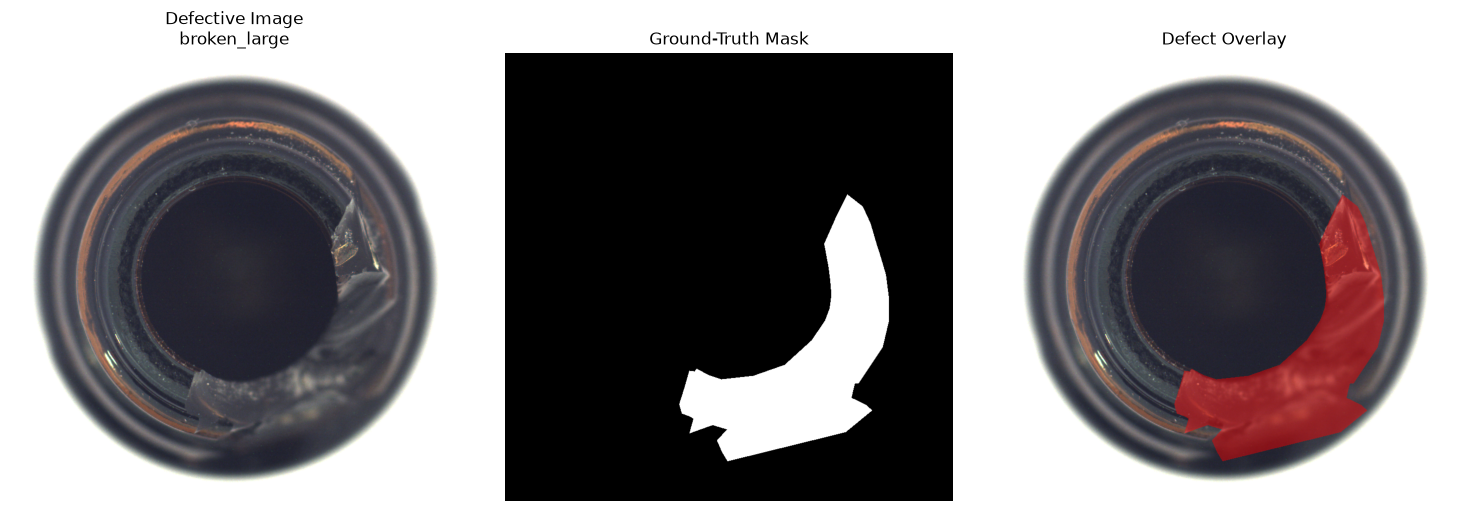

In [13]:
figure, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(defective_array)
axes[0].set_title(f"Defective Image\n{DEFECT_TYPE}")
axes[0].axis("off")

axes[1].imshow(mask_array, cmap="gray")
axes[1].set_title("Ground-Truth Mask")
axes[1].axis("off")

axes[2].imshow(overlay_image)
axes[2].set_title("Defect Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [14]:
def create_defect_overlay(
    image_array: np.ndarray,
    mask_array: np.ndarray,
    alpha: float = 0.45,
) -> np.ndarray:

    binary_mask = mask_array > 0
    overlay = image_array.copy()

    red_highlight = np.zeros_like(image_array)
    red_highlight[:, :, 0] = 255

    overlay[binary_mask] = (
        (1 - alpha) * image_array[binary_mask]
        + alpha * red_highlight[binary_mask]
    ).astype(np.uint8)

    return overlay

In [15]:
test_categories = list_subdirectories(test_path)

category_samples = []

for test_category in test_categories:
    category_directory = test_path / test_category
    image_paths = get_image_files(category_directory)

    sample_path = image_paths[0]

    image = Image.open(sample_path).convert("RGB")
    image_array = np.array(image)

    if test_category == "good":
        mask_array = np.zeros(
            image_array.shape[:2],
            dtype=np.uint8,
        )
    else:
        mask_path = (
            ground_truth_path
            / test_category
            / f"{sample_path.stem}_mask.png"
        )

        mask = Image.open(mask_path).convert("L")
        mask_array = np.array(mask)

    overlay_array = create_defect_overlay(
        image_array,
        mask_array,
    )

    category_samples.append(
        {
            "category": test_category,
            "image_path": sample_path,
            "image": image_array,
            "mask": mask_array,
            "overlay": overlay_array,
        }
    )

print(f"Loaded {len(category_samples)} category samples.")

for sample in category_samples:
    print(
        f"{sample['category']:<20} "
        f"{sample['image_path'].name}"
    )

Loaded 4 category samples.
broken_large         000.png
broken_small         000.png
contamination        000.png
good                 000.png


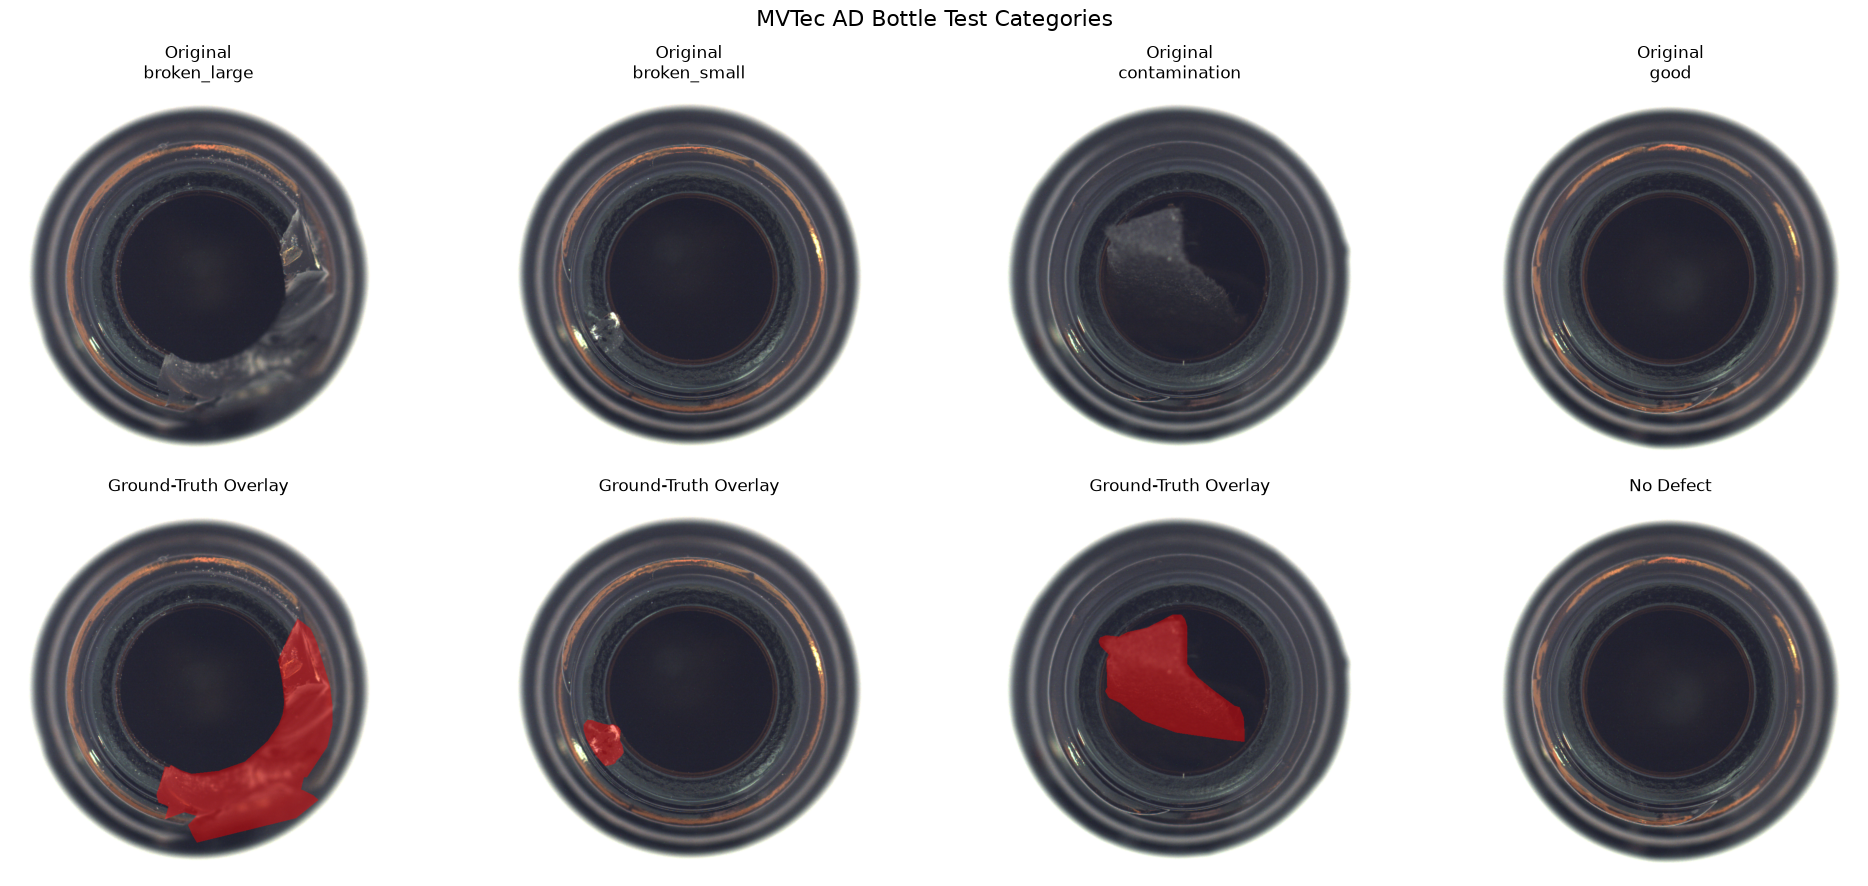

Figure saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\bottle_test_categories.png


In [16]:
number_of_categories = len(category_samples)

figure, axes = plt.subplots(
    2,
    number_of_categories,
    figsize=(5 * number_of_categories, 9),
)

for column_index, sample in enumerate(category_samples):
    axes[0, column_index].imshow(sample["image"])
    axes[0, column_index].set_title(
        f"Original\n{sample['category']}"
    )
    axes[0, column_index].axis("off")

    axes[1, column_index].imshow(sample["overlay"])

    if sample["category"] == "good":
        overlay_title = "No Defect"
    else:
        overlay_title = "Ground-Truth Overlay"

    axes[1, column_index].set_title(overlay_title)
    axes[1, column_index].axis("off")

plt.suptitle(
    "MVTec AD Bottle Test Categories",
    fontsize=16,
)

plt.tight_layout()

output_figure_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "bottle_test_categories.png"
)

plt.savefig(
    output_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to:\n{output_figure_path}")

In [17]:
image_metadata = []

for split_name, split_path in [
    ("train", train_path),
    ("test", test_path),
]:
    for image_path in sorted(split_path.rglob("*")):
        if (
            image_path.is_file()
            and image_path.suffix.lower() in IMAGE_EXTENSIONS
        ):
            with Image.open(image_path) as image:
                image_metadata.append(
                    {
                        "split": split_name,
                        "defect_type": image_path.parent.name,
                        "filename": image_path.name,
                        "width": image.width,
                        "height": image.height,
                        "mode": image.mode,
                    }
                )

image_metadata_df = pd.DataFrame(image_metadata)

print(f"Total images inspected: {len(image_metadata_df)}")

image_metadata_df.head()

Total images inspected: 292


,split,defect_type,filename,width,height,mode
0,train,good,000.png,900,900,RGB
1,train,good,001.png,900,900,RGB
2,train,good,002.png,900,900,RGB
3,train,good,003.png,900,900,RGB
4,train,good,004.png,900,900,RGB


In [18]:
size_summary_df = (
    image_metadata_df
    .groupby(
        ["split", "defect_type", "width", "height", "mode"]
    )
    .size()
    .reset_index(name="image_count")
    .sort_values(
        ["split", "defect_type", "width", "height"]
    )
)

size_summary_df

,split,defect_type,width,height,mode,image_count
0,test,broken_large,900,900,RGB,20
1,test,broken_small,900,900,RGB,22
2,test,contamination,900,900,RGB,21
3,test,good,900,900,RGB,20
4,train,good,900,900,RGB,209


In [19]:
print("BOTTLE IMAGE DIMENSION SUMMARY")

print("Unique widths:")
print(sorted(image_metadata_df["width"].unique()))

print("\nUnique heights:")
print(sorted(image_metadata_df["height"].unique()))

print("\nImage colour modes:")
print(image_metadata_df["mode"].value_counts())

print("\nDimension statistics:")
display(
    image_metadata_df[["width", "height"]].describe()
)

BOTTLE IMAGE DIMENSION SUMMARY
Unique widths:
[np.int64(900)]

Unique heights:
[np.int64(900)]

Image colour modes:
mode
RGB    292
Name: count, dtype: int64

Dimension statistics:


,width,height
count,292.0,292.0
mean,900.0,900.0
std,0.0,0.0
min,900.0,900.0
25%,900.0,900.0
50%,900.0,900.0
75%,900.0,900.0
max,900.0,900.0


In [20]:
metadata_output_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "bottle_image_metadata.csv"
)

image_metadata_df.to_csv(
    metadata_output_path,
    index=False,
)

print(f"Image metadata saved to:\n{metadata_output_path}")

Image metadata saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\bottle_image_metadata.csv


## Image preprocessing

The original bottle images are 900 × 900 RGB images.

For the convolutional autoencoder baseline, images will be:

1. resized to 256 × 256,
2. converted to PyTorch tensors,
3. scaled from pixel values `[0, 255]` to `[0.0, 1.0]`.

Ground-truth masks are resized using nearest-neighbour interpolation so that their binary boundaries are preserved.

In [21]:
import torch
from torchvision import transforms
from torchvision.transforms import InterpolationMode

IMAGE_SIZE = 256

image_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.ToTensor(),
    ]
)

mask_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=InterpolationMode.NEAREST,
        ),
        transforms.ToTensor(),
    ]
)

print("Target image size:", IMAGE_SIZE)
print(image_transform)

Target image size: 256
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [22]:
sample_image = Image.open(sample_image_path).convert("RGB")
sample_mask = Image.open(sample_mask_path).convert("L")

image_tensor = image_transform(sample_image)
mask_tensor = mask_transform(sample_mask)

# Ensure the resized mask remains binary.
mask_tensor = (mask_tensor > 0.5).float()

print("Original image size:", sample_image.size)
print("Original mask size:", sample_mask.size)

print("\nProcessed image tensor:")
print("Shape:", image_tensor.shape)
print("Data type:", image_tensor.dtype)
print("Minimum:", image_tensor.min().item())
print("Maximum:", image_tensor.max().item())

print("\nProcessed mask tensor:")
print("Shape:", mask_tensor.shape)
print("Data type:", mask_tensor.dtype)
print("Unique values:", torch.unique(mask_tensor).tolist())

Original image size: (900, 900)
Original mask size: (900, 900)

Processed image tensor:
Shape: torch.Size([3, 256, 256])
Data type: torch.float32
Minimum: 0.11764705926179886
Maximum: 1.0

Processed mask tensor:
Shape: torch.Size([1, 256, 256])
Data type: torch.float32
Unique values: [0.0, 1.0]


In [23]:
resized_image_array = (
    image_tensor
    .permute(1, 2, 0)
    .numpy()
)

resized_mask_array = (
    mask_tensor
    .squeeze(0)
    .numpy()
)

resized_overlay = create_defect_overlay(
    (resized_image_array * 255).astype(np.uint8),
    (resized_mask_array * 255).astype(np.uint8),
)

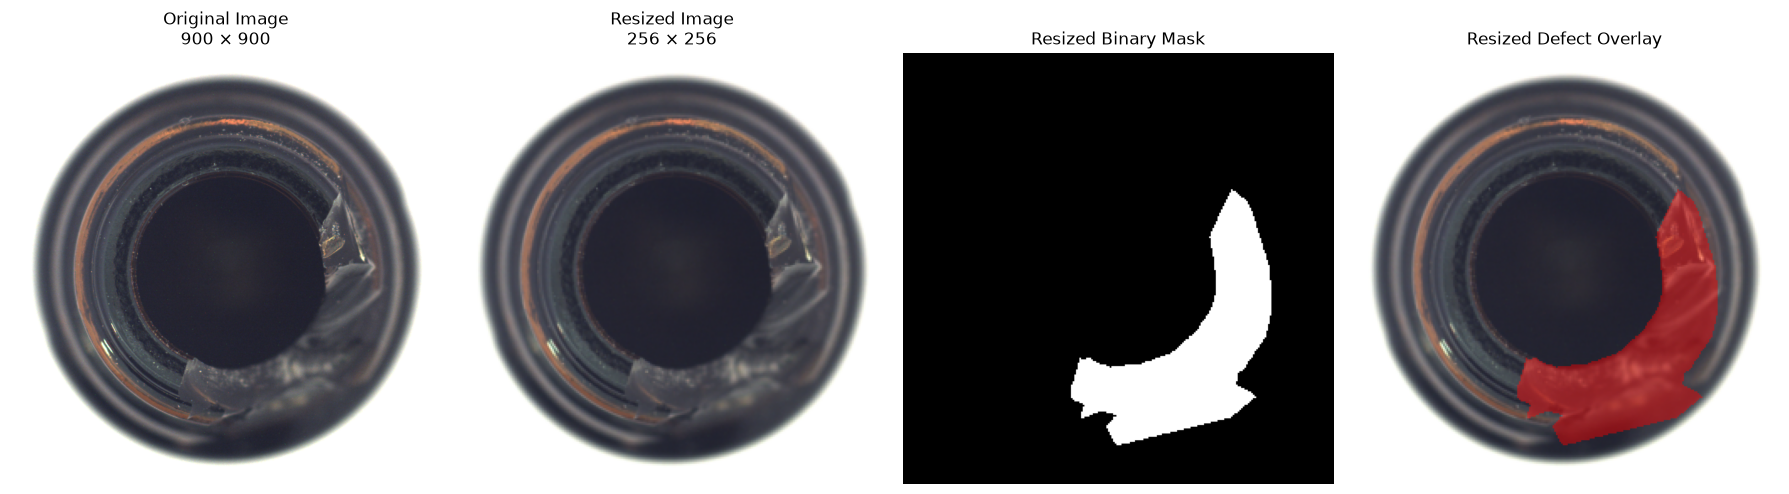

Figure saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\bottle_preprocessing_example.png


In [24]:
figure, axes = plt.subplots(
    1,
    4,
    figsize=(18, 5),
)

axes[0].imshow(sample_image)
axes[0].set_title("Original Image\n900 × 900")
axes[0].axis("off")

axes[1].imshow(resized_image_array)
axes[1].set_title("Resized Image\n256 × 256")
axes[1].axis("off")

axes[2].imshow(resized_mask_array, cmap="gray")
axes[2].set_title("Resized Binary Mask")
axes[2].axis("off")

axes[3].imshow(resized_overlay)
axes[3].set_title("Resized Defect Overlay")
axes[3].axis("off")

plt.tight_layout()

preprocessing_figure_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "bottle_preprocessing_example.png"
)

plt.savefig(
    preprocessing_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to:\n{preprocessing_figure_path}")

In [25]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.mvtec_dataset import MVTecDataset

In [26]:
train_dataset = MVTecDataset(
    dataset_root=DATASET_ROOT,
    category="bottle",
    split="train",
    image_size=256,
)

test_dataset = MVTecDataset(
    dataset_root=DATASET_ROOT,
    category="bottle",
    split="test",
    image_size=256,
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 209
Testing samples: 83


In [27]:
sample = test_dataset[0]

print("Image shape:", sample["image"].shape)
print("Mask shape:", sample["mask"].shape)
print("Label:", sample["label"].item())
print("Defect type:", sample["defect_type"])
print("Image path:", sample["image_path"])
print("Mask values:", torch.unique(sample["mask"]).tolist())

Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Label: 1
Defect type: broken_large
Image path: D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_ad\bottle\test\broken_large\000.png
Mask values: [0.0, 1.0]


In [28]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))
print("Batch size:", BATCH_SIZE)

Training batches: 27
Testing batches: 11
Batch size: 8


In [29]:
train_batch = next(iter(train_loader))

print("Batch keys:", train_batch.keys())
print("Image batch shape:", train_batch["image"].shape)
print("Mask batch shape:", train_batch["mask"].shape)
print("Label batch shape:", train_batch["label"].shape)

print("Labels:", train_batch["label"].tolist())
print("Defect types:", train_batch["defect_type"])

Batch keys: dict_keys(['image', 'mask', 'label', 'defect_type', 'image_path'])
Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 1, 256, 256])
Label batch shape: torch.Size([8])
Labels: [0, 0, 0, 0, 0, 0, 0, 0]
Defect types: ['good', 'good', 'good', 'good', 'good', 'good', 'good', 'good']


In [30]:
from torch.utils.data import random_split

RANDOM_SEED = 42
VALIDATION_RATIO = 0.20

validation_size = int(len(train_dataset) * VALIDATION_RATIO)
training_size = len(train_dataset) - validation_size

split_generator = torch.Generator().manual_seed(RANDOM_SEED)

training_subset, validation_subset = random_split(
    train_dataset,
    lengths=[training_size, validation_size],
    generator=split_generator,
)

print("Complete normal dataset:", len(train_dataset))
print("Training subset:", len(training_subset))
print("Validation subset:", len(validation_subset))
print("Total after split:", len(training_subset) + len(validation_subset))

Complete normal dataset: 209
Training subset: 168
Validation subset: 41
Total after split: 209


In [31]:
train_loader = DataLoader(
    training_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

validation_loader = DataLoader(
    validation_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Testing batches:", len(test_loader))

Training batches: 21
Validation batches: 6
Testing batches: 11


In [32]:
def collect_labels(data_loader: DataLoader) -> list[int]:
    """Collect all labels from a DataLoader."""
    labels = []

    for batch in data_loader:
        labels.extend(batch["label"].tolist())

    return labels


training_labels = collect_labels(train_loader)
validation_labels = collect_labels(validation_loader)

print("Unique training labels:", sorted(set(training_labels)))
print("Unique validation labels:", sorted(set(validation_labels)))

assert set(training_labels) == {0}
assert set(validation_labels) == {0}

print("Training and validation sets contain only normal images.")

Unique training labels: [0]
Unique validation labels: [0]
Training and validation sets contain only normal images.
